In [1]:
import sys
sys.path.append("../../mymodule")
from utilfunc import *
from backprojection_sky import *

In [2]:
filePath = "/Users/takashima/work/grams/nanograms-analysis/run10/products/z0cm/compton.root"

branchList = ["hit1_energy", "hit1_posx", "hit1_posy", "hit1_posz", 
              "hit2_energy", "hit2_posx", "hit2_posy", "hit2_posz",
              "costheta"]
dataDict = uproot.open(f"{filePath}:cetree").arrays(branchList, cut="num_hits==2", library="np")
dataDict["theta_k"] = np.acos(dataDict["costheta"])

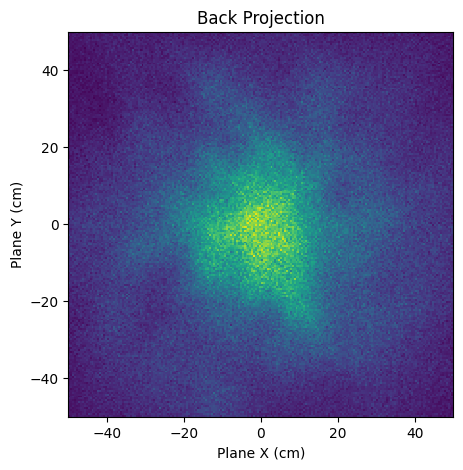

In [3]:
plane_point  = np.array([50.0, 0.0, 0.0])
plane_normal = np.array([1.0, 0.0, 0.0])
plane_yaxis  = np.array([0.0, 0.0, 1.0])
spread_arm   = np.deg2rad(3)

plotBackProjection(
    dataDict,
    plane_point,
    plane_normal,
    plane_yaxis,
    spread_arm,
    num_points=10000,
    xRange=(-50,50),
    yRange=(-50,50),
    numBinsXY=200,
    numBinsX=None,
    numBinsY=None,
    title=None,
    figName=None,
    xlabel="Plane X (cm)",
    ylabel="Plane Y (cm)",
)

(<Figure size 850x540 with 2 Axes>,
 array([0.0061, 0.0053, 0.0066, ..., 0.0023, 0.0028, 0.0025],
       shape=(49152,)))

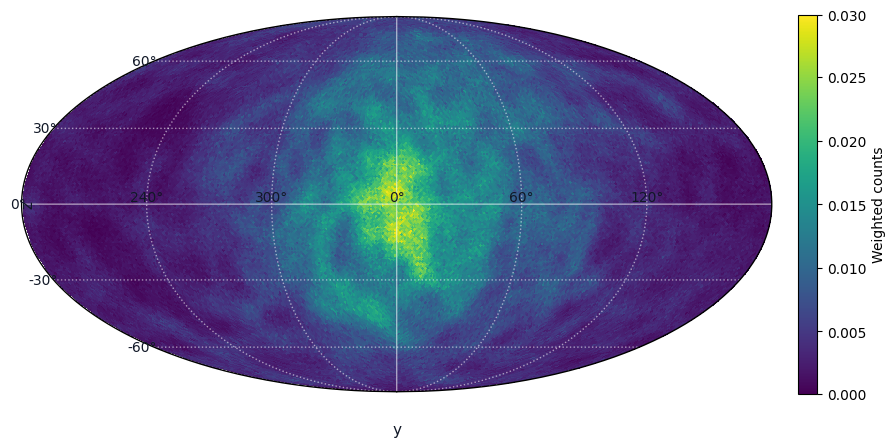

In [7]:
plot_healpix_backprojection_mollweide(
    dataDict,
    spread_arm,
    nside = 64,
    num_points = 10000,
    title = "",
    unit = "Weighted counts",
    figName = None,
    return_map = True,
)
